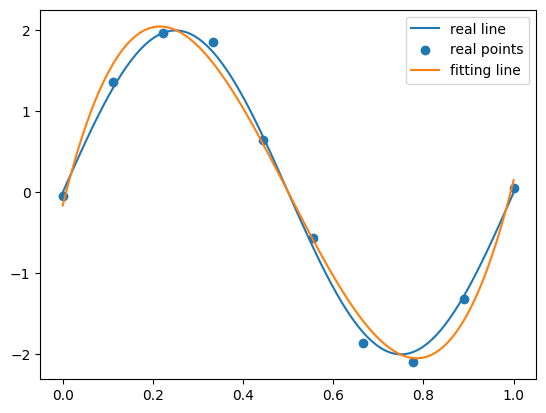

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import leastsq


# 数据点分布在这条曲线附近
def func(x):
    return 2*np.sin(2*np.pi*x)

# 误差函数， 计算拟合曲线与真实数据点之间的差 ，作为leastsq函数的输入
def residuals(p, x, y):
    fun = np.poly1d(p)    # poly1d（）函数可以按照输入的列表p返回一个多项式函数
    return y - fun(x)

# 拟合函数
def fitting(p):
    pars = np.random.rand(p+1)  # 生成p+1个随机数的列表，这样poly1d函数返回的多项式次数就是p
    r = leastsq(residuals, pars, args=(X, Y))   # 三个参数：误差函数、函数参数列表、数据点
    return r

# 要进行拟合的数据点
X = np.linspace(0, 1, 10)
Y = [np.random.normal(0, 0.1)+num for num in func(X)]  # 添加噪声

# 方便绘制曲线，所以创建
x_ = np.linspace(0, 1, 100)
y_ = func(x_)

# print(fitting(3))   可以看一下返回的是什么
fit_pars = fitting(3)[0]

plt.plot(x_, y_, label='real line')
plt.scatter(X, Y, label='real points')
plt.plot(x_, np.poly1d(fit_pars)(x_), label='fitting line')
plt.legend()
plt.show()

count = 1000
count // 2 + 1 = 501
result = (array([ 69, 112, 162, 220, 264, 317, 366, 411, 455, 516, 561, 603, 662,
       717, 762, 815, 859, 915, 964]),)


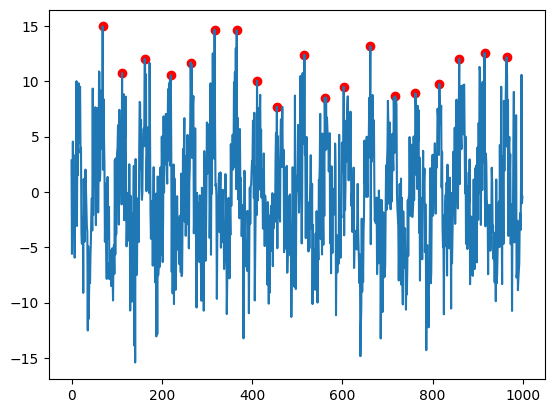

In [15]:


def AMPD(data):
    """
    实现AMPD算法
    :param data: 1-D numpy.ndarray
    :return: 波峰所在索引值的列表
    """
    p_data = np.zeros_like(data, dtype=np.int32)
    count = data.shape[0]
    print('count =', count)
    print('count // 2 + 1 =', count // 2 + 1)
    arr_rowsum = []
    for k in range(1, count // 2 + 1):
        row_sum = 0
        for i in range(k, count - k):
            if data[i] > data[i - k] and data[i] > data[i + k]:
                row_sum -= 1
        arr_rowsum.append(row_sum)
    min_index = np.argmin(arr_rowsum)
    max_window_length = min_index
    for k in range(1, max_window_length + 1):
        for i in range(k, count - k):
            if data[i] > data[i - k] and data[i] > data[i + k]:
                p_data[i] += 1
    result =np.where(p_data == max_window_length)
    print('result =', result)
    return result[0]


def sim_data():
    N = 1000
    x = np.linspace(0, 200, N)
    y = 2 * np.cos(2 * np.pi * 300 * x) \
        + 5 * np.sin(2 * np.pi * 100 * x) \
        + 4 * np.random.randn(N)
    return y

def vis():
    y = sim_data()
    plt.plot(range(len(y)), y)
    px = AMPD(y)
    plt.scatter(px, y[px], color="red")

    plt.show()

vis()

          7             6             5             4            3
5.37e-18 x - 1.982e-14 x + 2.897e-11 x - 2.126e-08 x + 8.17e-06 x
             2
 - 0.001545 x + 0.1155 x - 1.403


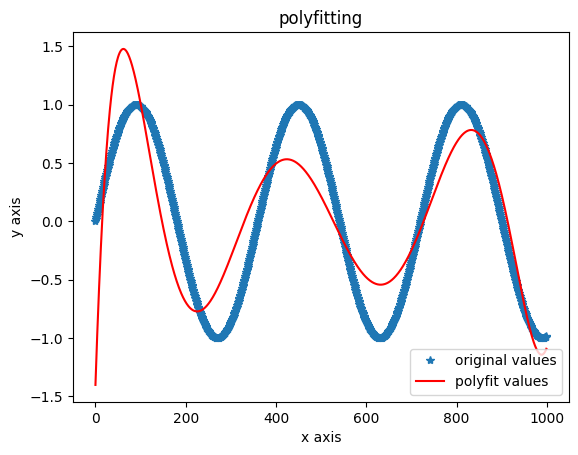

[ 62 424 833]
the number of peaks is 3


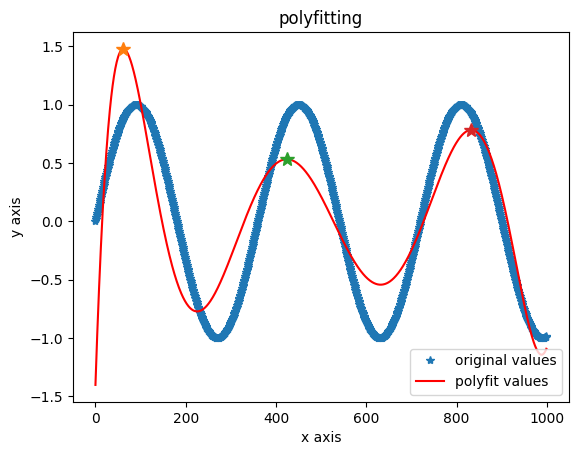

[1.47679325 0.53103223 0.78196748]
(array([ 62, 424, 833]),)


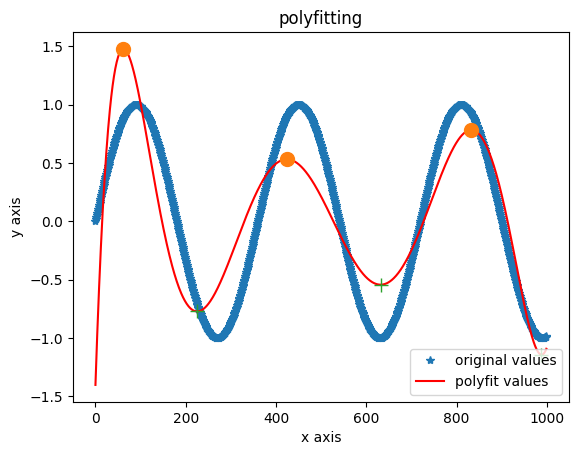

In [7]:

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal #滤波等

xxx = np.arange(0, 1000)
yyy = np.sin(xxx*np.pi/180)
z1 = np.polyfit(xxx, yyy, 7) # 用7次多项式拟合
p1 = np.poly1d(z1) #多项式系数
print(p1) # 在屏幕上打印拟合多项式
yvals=p1(xxx)
plt.plot(xxx, yyy, '*',label='original values')
plt.plot(xxx, yvals, 'r',label='polyfit values')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.legend(loc=4)
plt.title('polyfitting')
plt.show()

# 极值
num_peak_3 = signal.find_peaks(yvals, distance=10) #distance表极大值点的距离至少大于等于10个水平单位
print(num_peak_3[0])
print('the number of peaks is ' + str(len(num_peak_3[0])))
plt.plot(xxx, yyy, '*',label='original values')
plt.plot(xxx, yvals, 'r',label='polyfit values')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.legend(loc=4)
plt.title('polyfitting')
for ii in range(len(num_peak_3[0])):
    plt.plot(num_peak_3[0][ii], yvals[num_peak_3[0][ii]],'*',markersize=10)
plt.show()


yyyd = np.polyder(p1,1) # 1表示一阶导
print(yyyd)

print(yvals[signal.argrelextrema(yvals, np.greater)]) #极大值的y轴, yvals为要求极值的序列
print(signal.argrelextrema(yvals, np.greater)) #极大值的x轴
peak_ind = signal.argrelextrema(yvals,np.greater)[0] #极大值点，改为np.less即可得到极小值点
plt.plot(xxx, yyy, '*',label='original values')
plt.plot(xxx, yvals, 'r',label='polyfit values')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.legend(loc=4)
plt.title('polyfitting')
plt.plot(signal.argrelextrema(yvals,np.greater)[0],yvals[signal.argrelextrema(yvals, np.greater)],'o', markersize=10) #极大值点

plt.plot(signal.argrelextrema(yvals,np.less)[0],yvals[signal.argrelextrema(yvals, np.less)],'+', markersize=10) #极小值点
plt.show()

[findpeaks] >Finding peaks in 1d-vector using [topology] method..
[findpeaks] >Detect peaks using topology method with limit at None.


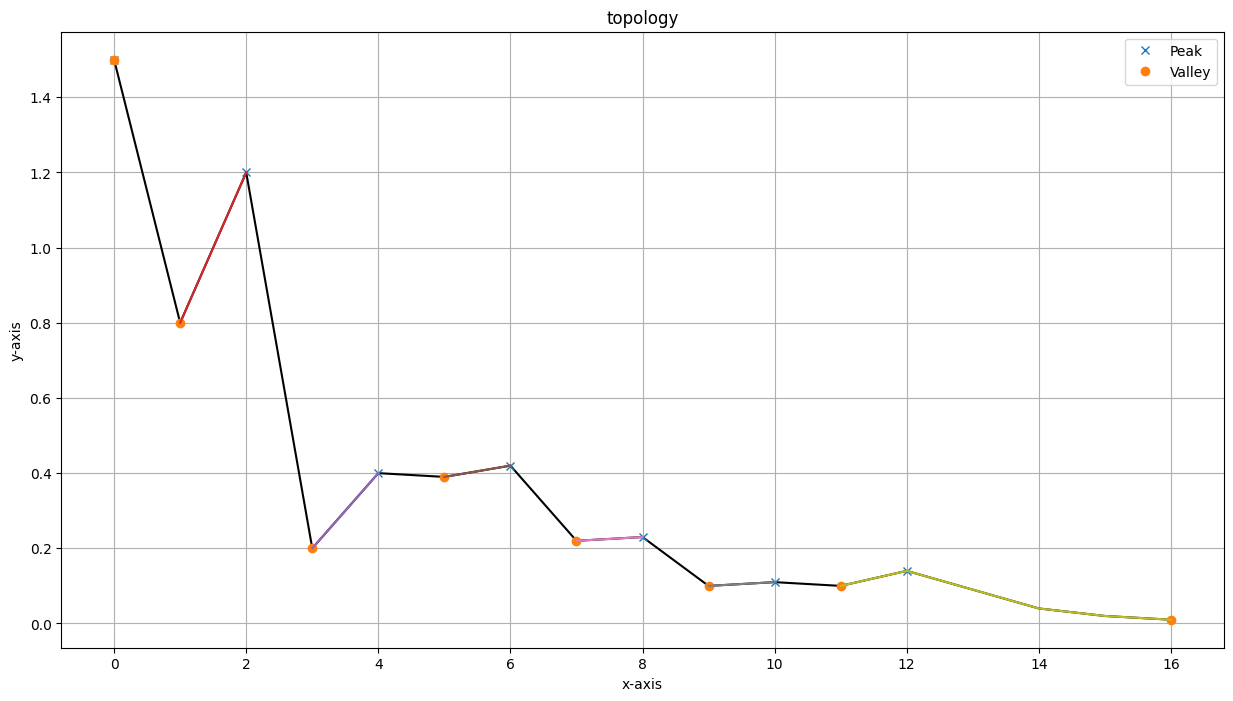

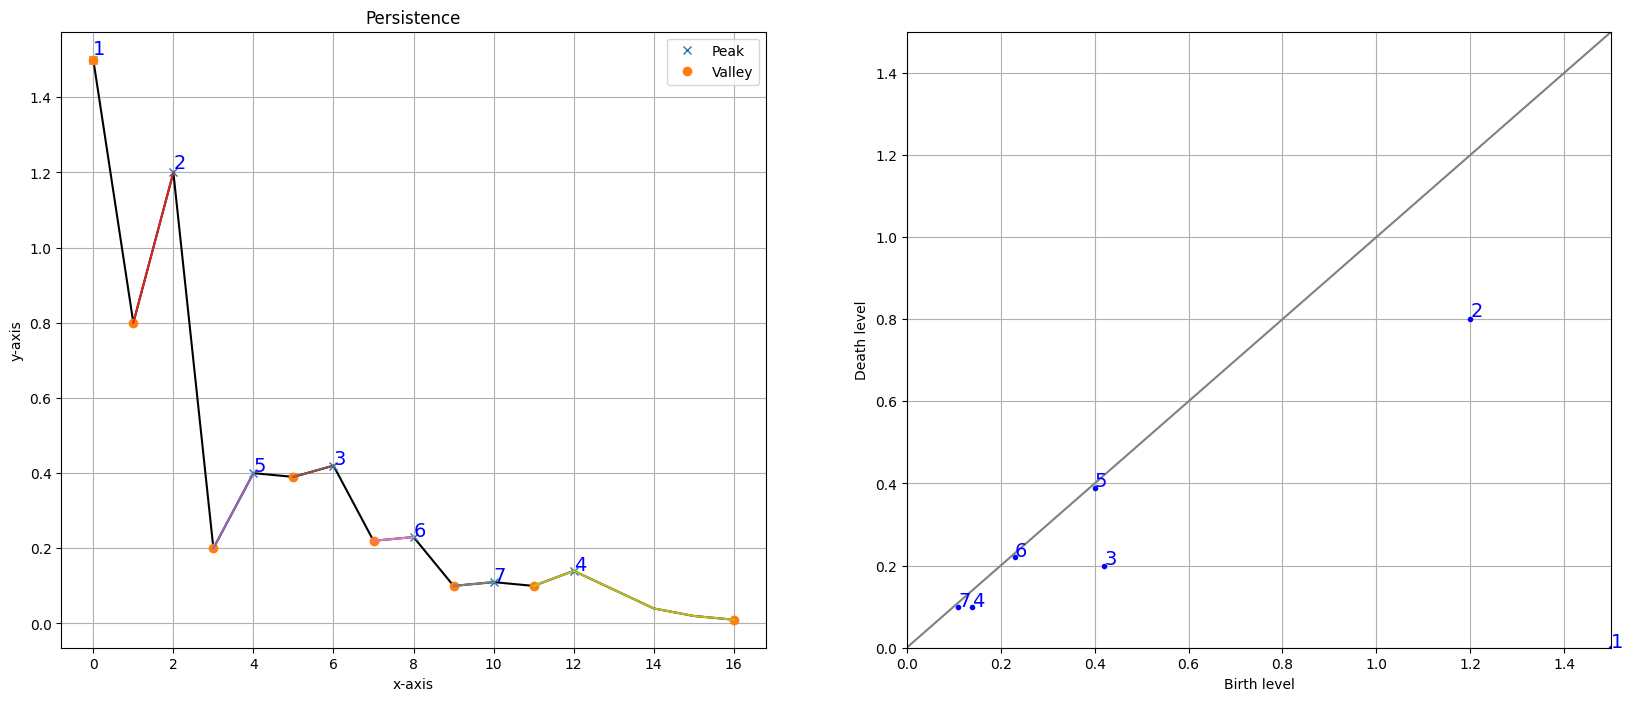

(<AxesSubplot: title={'center': 'Persistence'}, xlabel='x-axis', ylabel='y-axis'>,
 <AxesSubplot: xlabel='Birth level', ylabel='Death level'>)

In [17]:
# Import library
from findpeaks import findpeaks

# Initialized
fp = findpeaks(method='topology')

# Example data:
X = fp.import_example('1dpeaks')

# Peak detection
results = fp.fit(X)

# Plot
fp.plot()

# Plot
fp.plot_persistence()

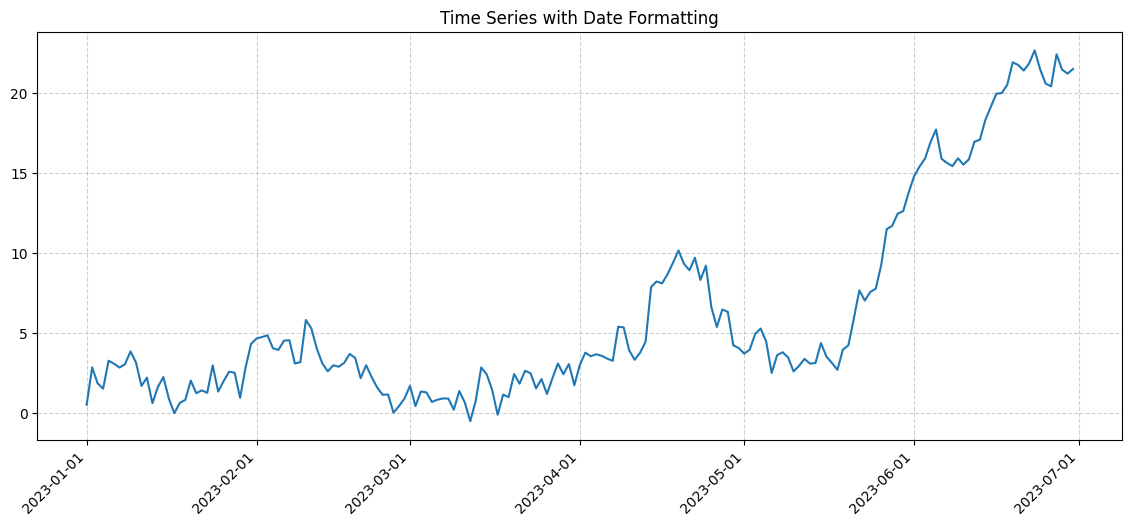

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 生成示例数据
dates = pd.date_range('2023-01-01', '2023-06-30', freq='D')
values = np.random.randn(len(dates)).cumsum()
data = pd.DataFrame({'value': values}, index=dates)

# 绘制图表
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['value'], label='Time Series')

# 设置日期格式
locator = mdates.AutoDateLocator()
formatter = mdates.DateFormatter('%Y-%m-%d')  # 格式：年-月-日
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)

# 优化标签显示
plt.gcf().autofmt_xdate(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Time Series with Date Formatting')
plt.show()